In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Option 1: Load directly via seaborn (no download needed)
#df = sns.load_dataset('titanic')

# Option 2: Download from Kaggle and load manually
df = pd.read_csv('Titanic-Dataset.csv')

print(df.shape)        # (891, 15)
print(df.head())
print(df.info())       # Column types + null counts
print(df.describe())   # Stats: mean, std, min, max

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [9]:
# ── Step 2: EDA ──────────────────────────────────────────────

# Survival counts
print(df['Survived'].value_counts())
print(df['Survived'].value_counts(normalize=True).round(2))
# Output: 0 → 0.62 (died),  1 → 0.38 (survived)

# Missing values — the most important check
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nMissing %:")
print((df.isnull().sum() / len(df) * 100).round(1))


Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing %:
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64


In [10]:
# ── Step 3: Preprocessing (complete, run once) ───────────────

# 1. Drop Cabin
df.drop(columns=['Cabin'], inplace=True)

# 2. Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# 3. Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 4. Encode Sex
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# 5. One-hot encode Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# 6. Drop PassengerId and Ticket
df.drop(columns=['PassengerId', 'Ticket'], inplace=True)

# 7. Fix boolean columns immediately
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)

# ── Verify ───────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head(3))

Shape: (891, 10)

Missing values:
 Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

Columns:
 ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

First 3 rows:
    Survived  Pclass                                               Name  Sex  \
0         0       3                            Braund, Mr. Owen Harris    1   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0   
2         1       3                             Heikkinen, Miss. Laina    0   

    Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S  
0  22.0      1      0   7.2500           0           1  
1  38.0      1      0  71.2833           0           0  
2  26.0      0      0   7.9250           0           1  


In [11]:
# ── Step 4: Feature Engineering ──────────────────────────────

# 1. Extract title from Name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Check all titles present in the dataset
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64


In [12]:
# 2. Group rare titles
df['Title'] = df['Title'].replace(
    ['Dr', 'Rev', 'Major', 'Col', 'Capt',
     'Sir', 'Lady', 'Countess', 'Don', 'Jonkheer'], 'Rare'
)

# Handle French titles — map to English equivalents
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',   # French for Miss
    'Ms'  : 'Miss',   # Variant of Miss
    'Mme' : 'Mrs'     # French for Mrs
})

# Verify — should now be exactly 5 categories
print(df['Title'].value_counts())


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [13]:
# 3. Encode Title as numbers
from sklearn.preprocessing import LabelEncoder
df['Title'] = LabelEncoder().fit_transform(df['Title'])

# 4. Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 5. Is alone?
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 6. Age × Pclass interaction
df['Age_Class'] = df['Age'] * df['Pclass']

# 7. Drop Name — done with it now
df.drop(columns=['Name'], inplace=True)

# ── Verify ───────────────────────────────────────────────────
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:\n", df.head(5))
print("\nTitle encoding mapping:")
print(sorted(df['Title'].unique()))


Shape: (891, 13)

Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'Title', 'FamilySize', 'IsAlone', 'Age_Class']

Sample:
    Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S  \
0         0       3    1  22.0      1      0   7.2500           0           1   
1         1       1    0  38.0      1      0  71.2833           0           0   
2         1       3    0  26.0      0      0   7.9250           0           1   
3         1       1    0  35.0      1      0  53.1000           0           1   
4         0       3    1  35.0      0      0   8.0500           0           1   

   Title  FamilySize  IsAlone  Age_Class  
0      2           2        0       66.0  
1      3           2        0       38.0  
2      1           1        1       78.0  
3      3           2        0       35.0  
4      2           1        1      105.0  

Title encoding mapping:
[0, 1, 2, 3, 4]


In [17]:
# ── Step 5: Split + Scale + Train ────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Separate features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

print("Features shape:", X.shape)   # (891, 12)
print("Target shape:", y.shape)     # (891,)
print("\nClass balance in target:")
print(y.value_counts(normalize=True).round(2))

# 2. Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps 62/38 ratio in both splits
)

print("\nTraining set size:", X_train.shape[0])
print("Test set size:    ", X_test.shape[0])

# 3. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # ONLY transform on test

# 4. Train Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# 5. Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

Features shape: (891, 12)
Target shape: (891,)

Class balance in target:
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

Training set size: 712
Test set size:     179


In [18]:
# Train both models
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

print("Both models trained successfully")


Both models trained successfully


In [19]:
# Accuracy
print("─── Accuracy ───────────────────────────────")
print(f"Logistic Regression : {accuracy_score(y_test, lr_preds):.4f}")
print(f"Random Forest       : {accuracy_score(y_test, rf_preds):.4f}")

# Classification report
print("\n─── Random Forest Classification Report ────")
print(classification_report(y_test, rf_preds,
      target_names=['Died', 'Survived']))

      

─── Accuracy ───────────────────────────────
Logistic Regression : 0.8101
Random Forest       : 0.8268

─── Random Forest Classification Report ────
              precision    recall  f1-score   support

        Died       0.82      0.92      0.87       110
    Survived       0.84      0.68      0.75        69

    accuracy                           0.83       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179



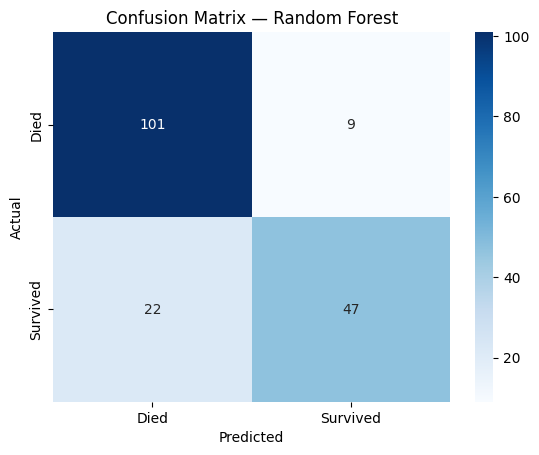

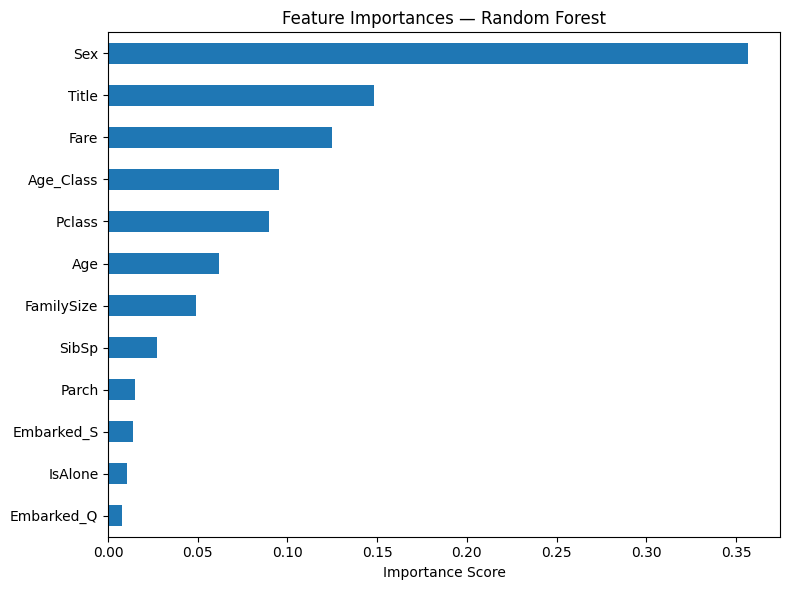

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.show()

# Feature importance
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
